In [2]:
"""
08_visualize_results.py — Publication-quality figures
Convert to notebook: jupytext --to notebook 08_visualize_results.py

Generates:
  1. Violin plots: 3-group (Control/OTC/nonOTC) × L/R hemi × 4 categories
  2. Summary table with patient percentiles
  3. Peak distance histograms

Handles multiple contrast maps via SUFFIX parameter.
"""

'\n08_visualize_results.py — Publication-quality figures\nConvert to notebook: jupytext --to notebook 08_visualize_results.py\n\nGenerates:\n  1. Violin plots: 3-group (Control/OTC/nonOTC) × L/R hemi × 4 categories\n  2. Summary table with patient percentiles\n  3. Peak distance histograms\n\nHandles multiple contrast maps via SUFFIX parameter.\n'

# Setup

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir, _load_csv

RESULTS = f'{processed_dir}/group_results'
CATEGORIES = ['face', 'word', 'house', 'object']

# ── Choose which analysis to visualize ──
# Options: '', '_category_vs_rest', '_broad', '_category_vs_rest_broad', '_wholehemi'
SUFFIX = ''

FIG_DIR = f'{RESULTS}/figures{SUFFIX}'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Suffix: "{SUFFIX}" → Figures: {FIG_DIR}')

Suffix: "" → Figures: /user_data/csimmon2/sym_pt/group_results/figures


# Load and Prepare Data

In [4]:
def load_selectivity(suffix=''):
    """Load selectivity CSV, filter to first post-surgical session per subject."""
    f = f'{RESULTS}/selectivity/selectivity_summary{suffix}.csv'
    if not os.path.exists(f):
        print(f'NOT FOUND: {f}')
        return None
    df = pd.read_csv(f)

    # First session per subject
    df['ses_int'] = df['ses'].astype(int)
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'first_ses'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['first_ses']].drop(columns=['ses_int', 'first_ses'])

    # Add patient code
    sub_info = _load_csv()
    for sub in df['sub'].unique():
        sc = sub.replace('sub-', '')
        rows = sub_info[sub_info['sub_clean'] == sc]
        if not rows.empty:
            code = rows.iloc[0].get('code', '')
            df.loc[df['sub'] == sub, 'code'] = code if pd.notna(code) and code != '' else sub
        else:
            df.loc[df['sub'] == sub, 'code'] = sub

    # Label hemispheres nicely
    df['hemi_label'] = df['hemi'].map({'left': 'Left', 'right': 'Right'})

    # Assign status for controls
    df['status'] = df['group'].apply(lambda g: 'control' if g == 'control' else 'patient')

    print(f'Loaded: {len(df)} rows, {df["sub"].nunique()} subjects '
          f'({df[df["group"]=="control"]["sub"].nunique()} ctrl, '
          f'{df[df["group"]!="control"]["sub"].nunique()} patients)')
    return df


def load_percentiles(suffix=''):
    """Load patient percentiles from bootstrap."""
    f = f'{RESULTS}/selectivity/patient_percentiles{suffix}.csv'
    if not os.path.exists(f):
        return None
    return pd.read_csv(f)


def load_resamples(metric, suffix=''):
    """Load bootstrap resamples for a metric."""
    f = f'{RESULTS}/selectivity/resamples/{metric}_resamples{suffix}.csv'
    if not os.path.exists(f):
        return None
    return pd.read_csv(f)


sel_df = load_selectivity(SUFFIX)
pct_df = load_percentiles(SUFFIX)

Loaded: 296 rows, 50 subjects (24 ctrl, 26 patients)


# Violin Plots — 3-Group Layout

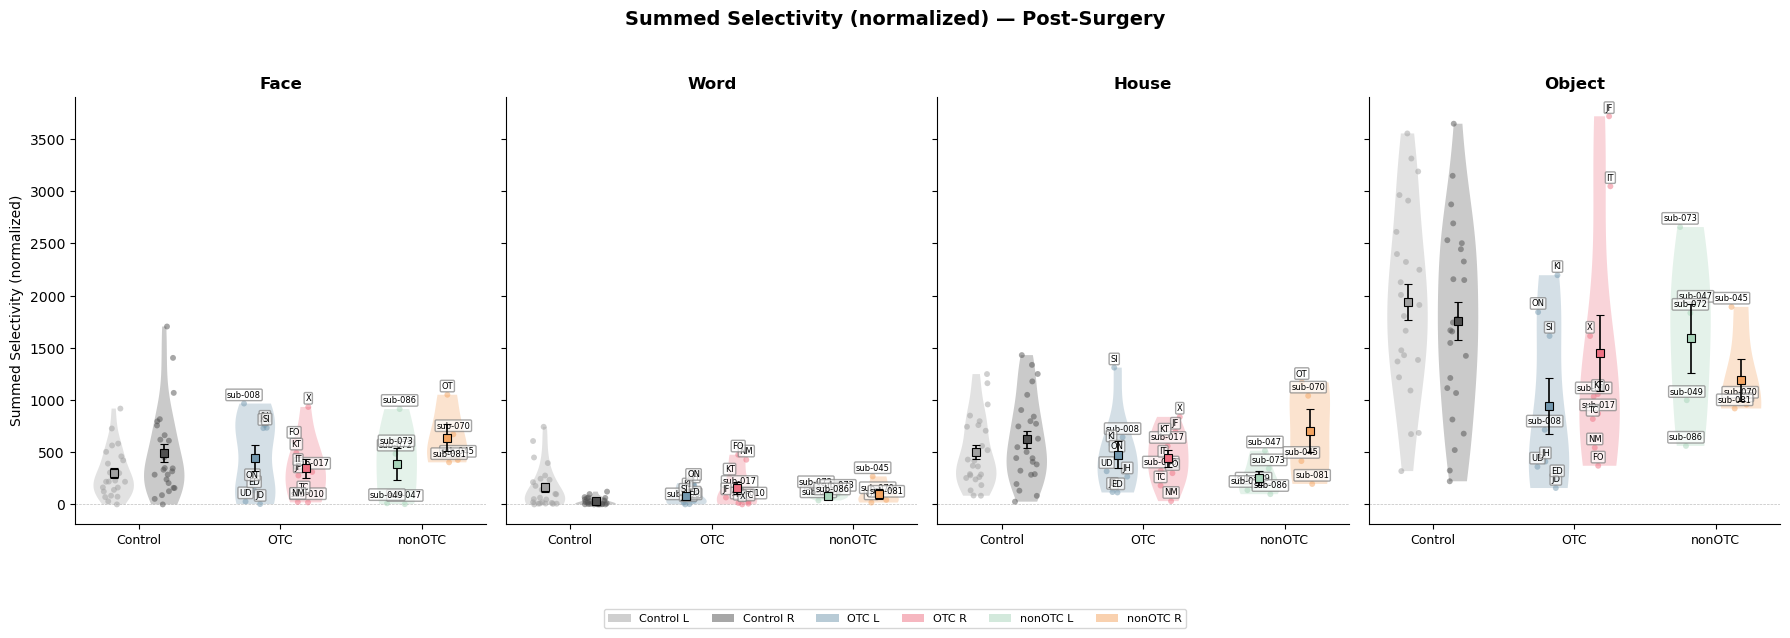

Saved: /user_data/csimmon2/sym_pt/group_results/figures/violin_sum_selec_norm_shared.png


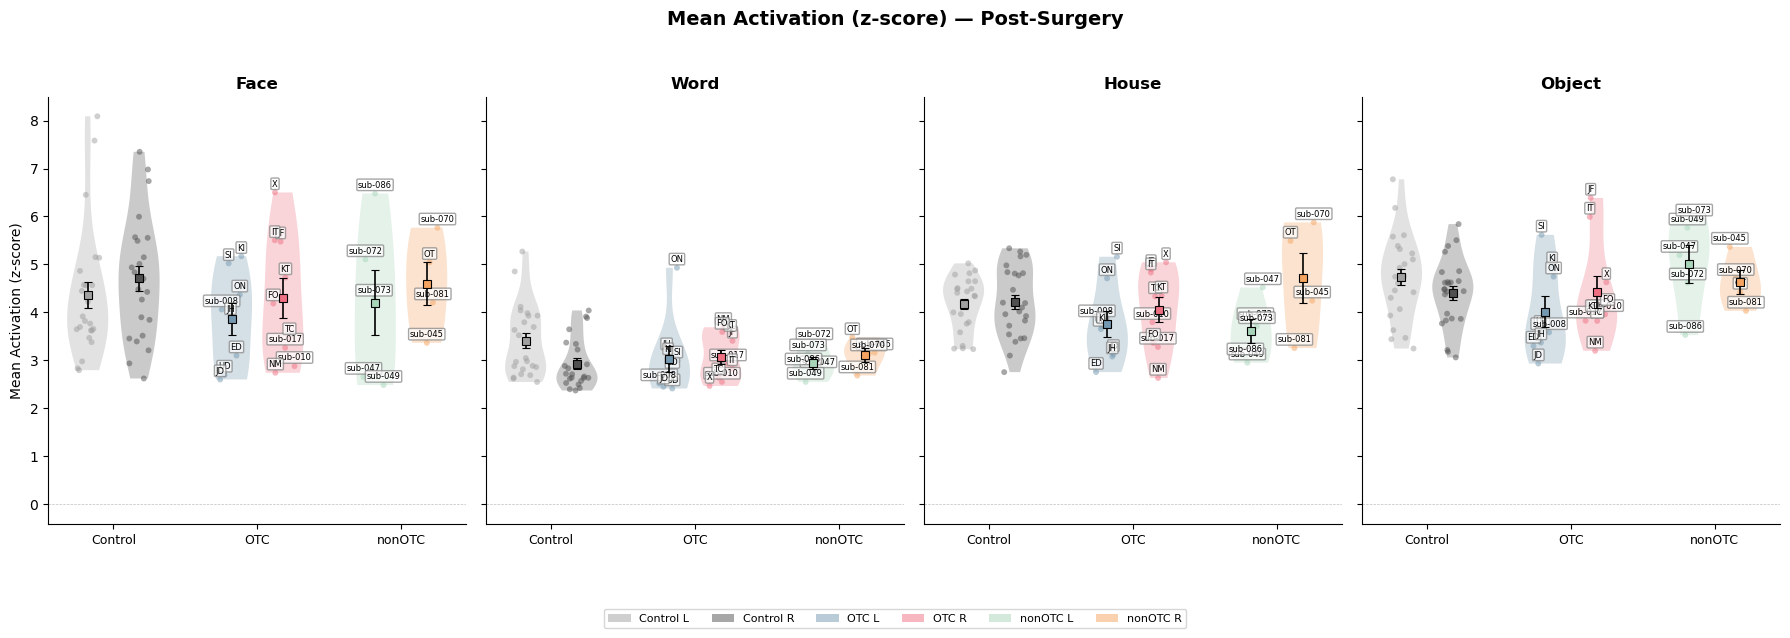

Saved: /user_data/csimmon2/sym_pt/group_results/figures/violin_mean_act_shared.png


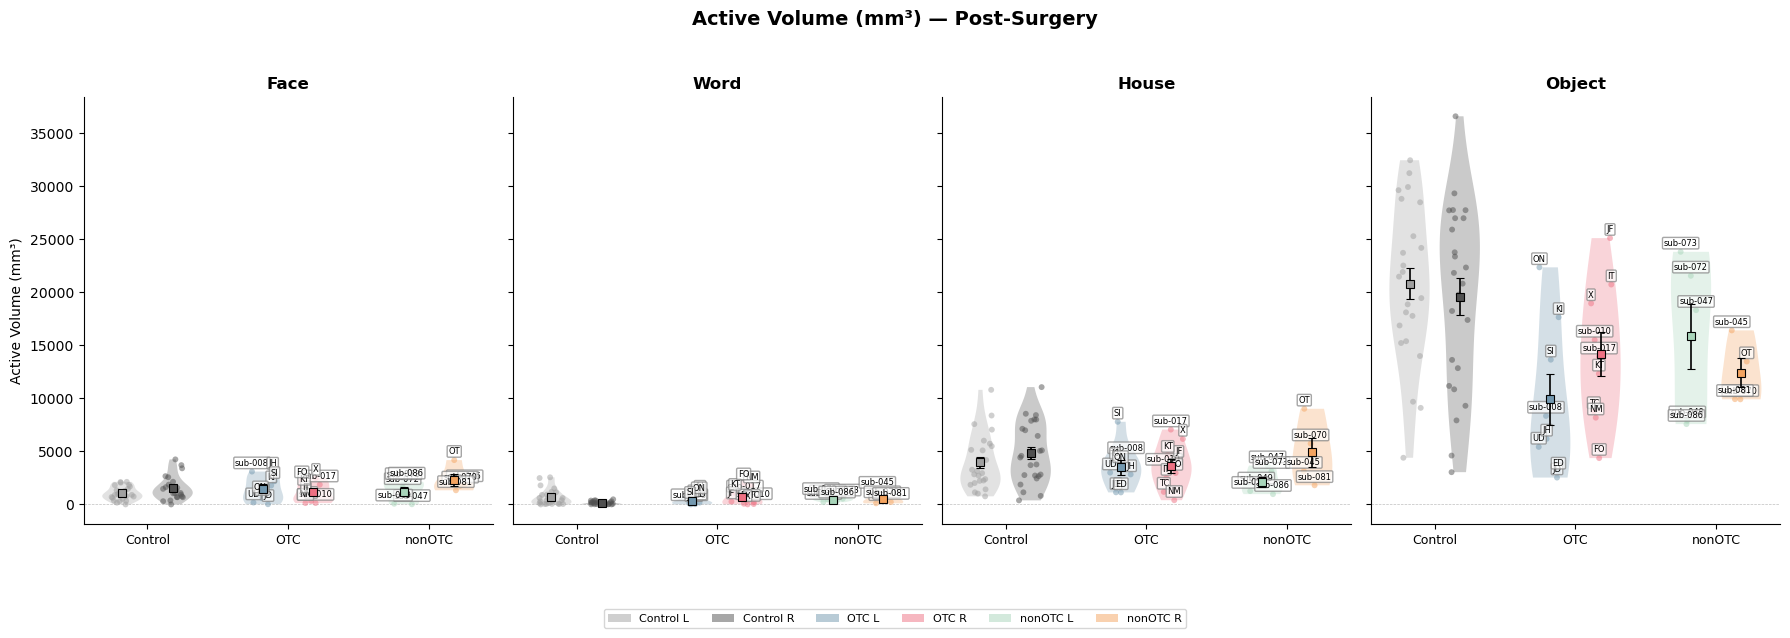

Saved: /user_data/csimmon2/sym_pt/group_results/figures/violin_volume_shared.png


In [5]:
def add_sig_bracket(ax, x1, x2, y, p, color='black'):
    """Add significance bracket above plot."""
    if p >= 0.05:
        return
    sig = '***' if p < .001 else '**' if p < .01 else '*'
    ax.plot([x1, x1, x2, x2], [y, y*1.02, y*1.02, y], color=color, lw=0.8)
    ax.text((x1+x2)/2, y*1.03, sig, ha='center', fontsize=8, color=color)


def plot_violins(df, metric='sum_selec_norm', ylabel='Summed Selectivity (normalized)',
                 suffix='', shared_y=True):
    """
    3-group × 2-hemisphere violin plot for each category.
    Controls: gray. OTC: blue/pink. nonOTC: green/orange.
    """
    if df is None:
        print('No data to plot')
        return

    slot_colors = {
        ('control', 'Left'):  '#a0a0a0', ('control', 'Right'): '#505050',
        ('OTC',     'Left'):  '#7398af', ('OTC',     'Right'): '#ee7183',
        ('nonOTC',  'Left'):  '#a8d5ba', ('nonOTC',  'Right'): '#f4a460',
    }

    plot_slots = [
        ('control', 'Left',  0.0),  ('control', 'Right', 0.5),
        ('OTC',     'Left',  1.4),  ('OTC',     'Right', 1.9),
        ('nonOTC',  'Left',  2.8),  ('nonOTC',  'Right', 3.3),
    ]

    fig, axes = plt.subplots(1, len(CATEGORIES),
                             figsize=(4.5 * len(CATEGORIES), 6),
                             sharey=shared_y)
    rng = np.random.default_rng(2)

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        cat_data = df[df['category'] == cat]
        vd, vp, vc = [], [], []

        for grp, hemi_lbl, pos in plot_slots:
            color = slot_colors[(grp, hemi_lbl)]
            hemi_code = 'left' if hemi_lbl == 'Left' else 'right'

            if grp == 'control':
                gd = cat_data[(cat_data['group'] == 'control') &
                              (cat_data['hemi'] == hemi_code)][metric].dropna().values
            else:
                gd = cat_data[(cat_data['group'] == grp) &
                              (cat_data['hemi'] == hemi_code)][metric].dropna().values

            if len(gd) < 2:
                if len(gd) > 0:
                    ax.scatter([pos], gd, color=color, alpha=0.6, s=20, zorder=3)
                continue

            vd.append(gd); vp.append(pos); vc.append(color)

            # Individual points with jitter
            jitter = rng.uniform(-0.12, 0.12, len(gd))
            ax.scatter(np.full(len(gd), pos) + jitter, gd,
                      color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')

            # Mean ± SE
            ax.errorbar(pos, np.mean(gd), yerr=np.std(gd)/np.sqrt(len(gd)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

            # Patient labels
            if grp != 'control':
                sub_rows = cat_data[(cat_data['group'] == grp) &
                                    (cat_data['hemi'] == hemi_code)]
                for idx, (_, row) in enumerate(sub_rows.iterrows()):
                    if pd.notna(row[metric]):
                        code = row.get('code', row['sub'])
                        if pd.isna(code) or code == '':
                            code = row['sub']
                        j = jitter[idx] if idx < len(jitter) else 0
                        ax.annotate(str(code), (pos + j, row[metric]),
                                   fontsize=6, ha='center', va='bottom',
                                   xytext=(0, 3), textcoords='offset points',
                                   bbox=dict(boxstyle='round,pad=0.15', fc='white',
                                            ec='gray', alpha=0.7))

        # Violins
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.4)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor('none')

        ax.set_xticks([0.25, 1.65, 3.05])
        ax.set_xticklabels(['Control', 'OTC', 'nonOTC'], fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        ax.axhline(0, color='gray', lw=0.5, linestyle='--', alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Legend
    legend_elements = [
        Patch(facecolor='#a0a0a0', alpha=0.5, label='Control L'),
        Patch(facecolor='#505050', alpha=0.5, label='Control R'),
        Patch(facecolor='#7398af', alpha=0.5, label='OTC L'),
        Patch(facecolor='#ee7183', alpha=0.5, label='OTC R'),
        Patch(facecolor='#a8d5ba', alpha=0.5, label='nonOTC L'),
        Patch(facecolor='#f4a460', alpha=0.5, label='nonOTC R'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=6, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.06))

    tag = 'shared' if shared_y else 'indep'
    plt.suptitle(f'{ylabel} — Post-Surgery', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    out = f'{FIG_DIR}/violin_{metric}_{tag}.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')


# Plot all three metrics
if sel_df is not None:
    plot_violins(sel_df, 'sum_selec_norm', 'Summed Selectivity (normalized)', SUFFIX)
    plot_violins(sel_df, 'mean_act', 'Mean Activation (z-score)', SUFFIX)
    plot_violins(sel_df, 'volume', 'Active Volume (mm³)', SUFFIX)

# Summary Table

In [6]:
def print_summary_table(pct_df, metric='sum_selec_norm'):
    """Print Ayzenberg-style Table 2."""
    if pct_df is None:
        print('No percentile data available')
        return

    ssn = pct_df[pct_df['metric'] == metric]
    if ssn.empty:
        print(f'No data for metric: {metric}')
        return

    # Get codes
    sub_info = _load_csv()
    def get_code(sub):
        sc = sub.replace('sub-', '')
        rows = sub_info[sub_info['sub_clean'] == sc]
        if rows.empty:
            return sub
        c = rows.iloc[0].get('code', '')
        return c if pd.notna(c) and c != '' else sub

    print('\n' + '=' * 90)
    print(f'SELECTIVITY TABLE ({metric})')
    print('* = below 95% CI, - = within/above')
    print('=' * 90)

    header = f'{"Patient":<12} {"Group":<8} {"Intact":<8}'
    for cat in CATEGORIES:
        header += f' {cat.capitalize():<14}'
    print(header)
    print('-' * 90)

    for sub in sorted(ssn['sub'].unique()):
        sub_data = ssn[ssn['sub'] == sub]
        intact = sub_data['intact_hemi'].iloc[0]
        group = sub_data['group'].iloc[0]
        code = get_code(sub)

        line = f'{code:<12} {group:<8} {intact:<8}'
        for cat in CATEGORIES:
            row = sub_data[sub_data['category'] == cat]
            if len(row) == 0:
                line += f' {"N/A":<14}'
            else:
                r = row.iloc[0]
                marker = '*' if r['below_ci'] else '-'
                line += f' {r["percentile"]:>6.1f}%{marker:<6}'
        print(line)

    print('=' * 90)


if pct_df is not None:
    print_summary_table(pct_df, 'sum_selec_norm')
    print_summary_table(pct_df, 'mean_act')
    print_summary_table(pct_df, 'volume')


SELECTIVITY TABLE (sum_selec_norm)
* = below 95% CI, - = within/above
Patient      Group    Intact   Face           Word           House          Object        
------------------------------------------------------------------------------------------
UD           OTC      left        0.0%*         0.0%*        13.8%-         0.0%*     
OT           nonOTC   right      99.0%-        27.1%-        99.7%-         3.4%-     
sub-008      OTC      left      100.0%-         2.5%*        80.5%-         0.0%*     
sub-010      OTC      right       0.0%*        44.3%-         6.0%-         4.9%-     
sub-017      OTC      right      20.4%-       100.0%-        39.2%-         2.1%*     
TC           OTC      right       0.2%*         7.5%-         0.5%*         1.6%*     
sub-045      nonOTC   right      42.1%-       100.0%-        15.5%-        61.3%-     
sub-047      nonOTC   left        0.0%*        23.8%-        55.9%-        46.9%-     
sub-049      nonOTC   left        0.0%*         7.6

# Peak Distance Analysis

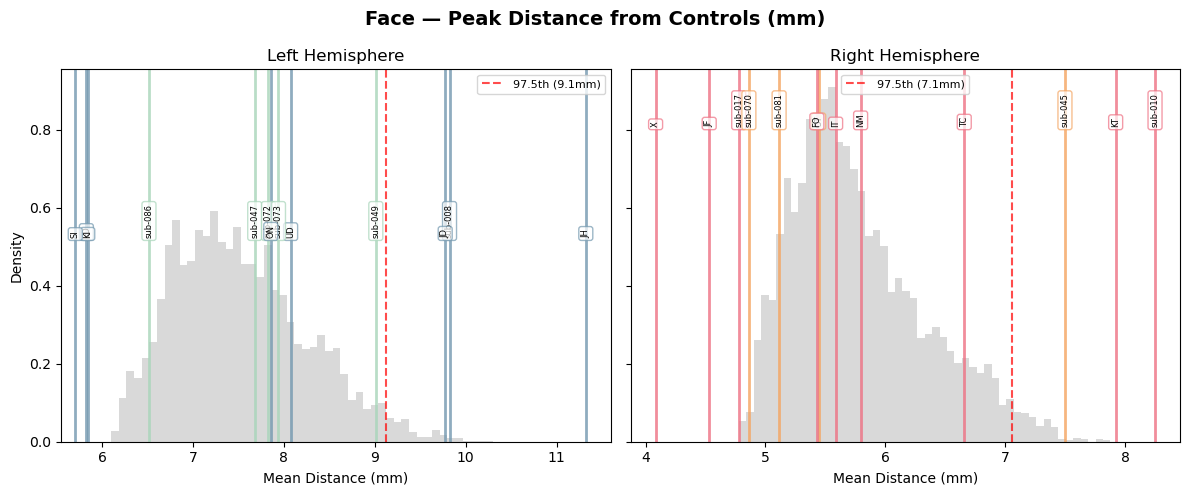

Saved: /user_data/csimmon2/sym_pt/group_results/figures/peak_dist_face.png


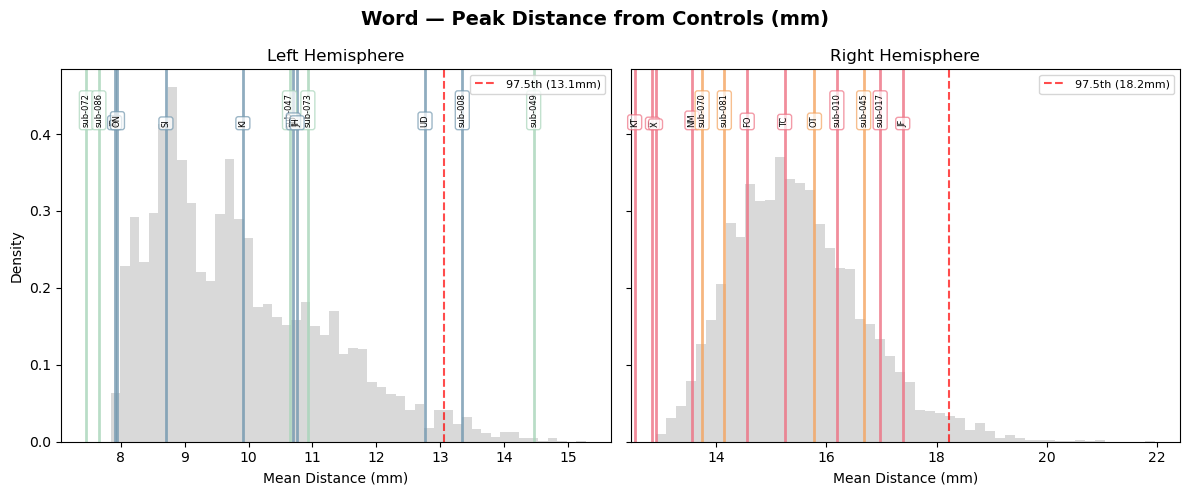

Saved: /user_data/csimmon2/sym_pt/group_results/figures/peak_dist_word.png


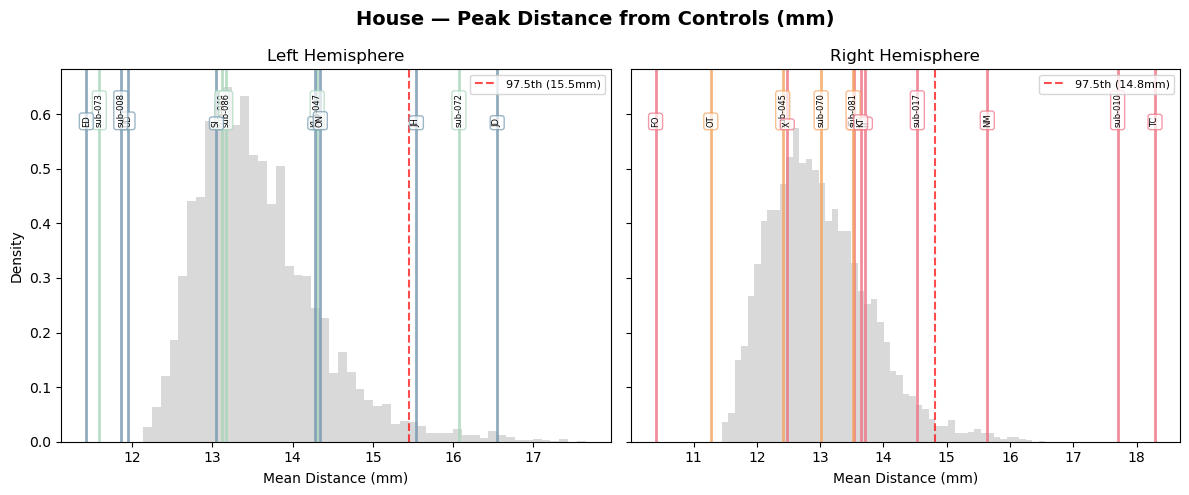

Saved: /user_data/csimmon2/sym_pt/group_results/figures/peak_dist_house.png


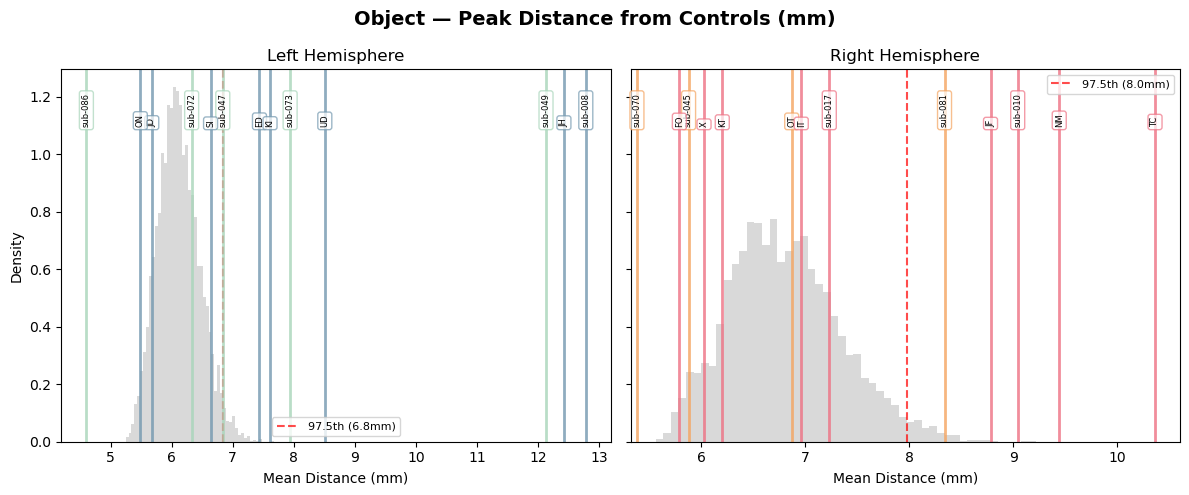

Saved: /user_data/csimmon2/sym_pt/group_results/figures/peak_dist_object.png


In [7]:
def plot_peak_distances(suffix=''):
    """Peak distance histograms with patient markers."""
    dist_f = f'{RESULTS}/peak_coords/patient_distances{suffix}.csv'
    resamp_f = f'{RESULTS}/peak_coords/distance_resamples{suffix}.csv'

    if not os.path.exists(dist_f) or not os.path.exists(resamp_f):
        print('Peak coordinate results not found.')
        return

    dist_df = pd.read_csv(dist_f)
    resamples = pd.read_csv(resamp_f)

    sub_info = _load_csv()
    def get_code(sub):
        sc = sub.replace('sub-', '')
        rows = sub_info[sub_info['sub_clean'] == sc]
        if rows.empty:
            return sub
        c = rows.iloc[0].get('code', '')
        return c if pd.notna(c) and c != '' else sub

    for cat in CATEGORIES:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        fig.suptitle(f'{cat.title()} — Peak Distance from Controls (mm)',
                     fontsize=14, fontweight='bold')

        for i, hemi in enumerate(['left', 'right']):
            ax = axes[i]
            col = f'{cat}_{hemi}'

            if col in resamples.columns:
                boot = resamples[col].dropna()
                ax.hist(boot, bins=50, color='#a0a0a0', alpha=0.4, density=True)
                ci97 = np.percentile(boot, 97.5)
                ax.axvline(ci97, color='red', ls='--', alpha=0.7,
                          label=f'97.5th ({ci97:.1f}mm)')

            pt = dist_df[(dist_df['category'] == cat) & (dist_df['hemi'] == hemi)]
            for _, row in pt.iterrows():
                color = '#7398af' if row['group'] == 'OTC' else '#a8d5ba'
                if row['intact_hemi'] == 'right':
                    color = '#ee7183' if row['group'] == 'OTC' else '#f4a460'
                code = get_code(row['sub'])
                ax.axvline(row['mean_dist_mm'], color=color, lw=2, alpha=0.8)
                ax.text(row['mean_dist_mm'], ax.get_ylim()[1] * 0.85, str(code),
                       fontsize=6, ha='center', rotation=90,
                       bbox=dict(fc='white', ec=color, alpha=0.7, boxstyle='round'))

            ax.set_title(f'{hemi.title()} Hemisphere')
            ax.set_xlabel('Mean Distance (mm)')
            if i == 0:
                ax.set_ylabel('Density')
            ax.legend(fontsize=8)

        plt.tight_layout()
        out = f'{FIG_DIR}/peak_dist_{cat}.png'
        plt.savefig(out, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out}')


plot_peak_distances(SUFFIX)

# Data Quality Check: Session Counts

In [8]:
if sel_df is not None:
    print('\n--- Session counts per subject (should be 1 after filtering) ---')
    ses_counts = sel_df.groupby('sub')['ses'].nunique()
    multi = ses_counts[ses_counts > 1]
    if len(multi) > 0:
        print(f'WARNING: {len(multi)} subjects have multiple sessions in data:')
        print(multi)
    else:
        print('OK: All subjects have exactly 1 session (first post-surgical)')

    print(f'\nTotal subjects: {sel_df["sub"].nunique()}')
    print(f'  Controls: {sel_df[sel_df["group"]=="control"]["sub"].nunique()}')
    print(f'  OTC: {sel_df[sel_df["group"]=="OTC"]["sub"].nunique()}')
    print(f'  nonOTC: {sel_df[sel_df["group"]=="nonOTC"]["sub"].nunique()}')


--- Session counts per subject (should be 1 after filtering) ---
OK: All subjects have exactly 1 session (first post-surgical)

Total subjects: 50
  Controls: 24
  OTC: 17
  nonOTC: 9
